## Oppgave 4
### a)


I denne oppgave ser vi hva som skjer når vi ser på partikler med hard core repulsion. Det betyr at partiklene ikke kan oppta samme posisjoner, at de har utstrekning, og at når de kolliderer så vil partiklene miste farten sin. Vi kan se på det som uelastiske støt. 
I koden under har vi brukt først opprettet et array som der indeks nummer 0 inneholder verdien til partikkel nummer 0 sin posisjon. 
Vi gjør en forenkling og sier at posisjonen lagret i arrayet params["initposition"] er venstre side av partikkelen. Partikkelen strekker seg lengde b til høyre.
Gjenbruker kode fra tidligere oppgaver, der vi hadde en flashing ratchet potential (av-på-skrallepotensial.)
Lager en ny funksjon som sjekker partiklene sannsynlighet til å gå en retning, og utfører handlingen dersom partikkelen ikke kolliderer med nabopartikkelen.
Til slutt bruker vi plotly-biblioteket til å printe posisjon.
Se diskusjon under plottet.


### Importerer biblioteker

In [28]:
import numpy as np
from matplotlib import pyplot as plt
import random
import plotly.graph_objects as go

In [29]:
"""Må inkludere disse bibliotekene for å plotte."""
# !pip install pandas
# !pip install plotly

'Må inkludere disse bibliotekene for å plotte.'

In [30]:
"""Oppretter først funksjonene. Definerer så variablene."""

# Bruker liste til å lagre posisjonene, for da vil vi kunne bruke det som indekser.
def MakeParticles(params, Np = False):   
    # I 4b) tar vi inn forskjellige størrelser.
    if Np == False:
        count = params["Np"]
    else:
        count = Np
    L = params["L"]
    size = params["b"]

    if (count) * (size) > L:
        print("Illegal size and particleamount. \n" \
        "Setting Particlecount to 1.")
        count = 1
        params["Np"] = count
            
    initParticlePos = np.linspace(0, L-size, count)

    listPosition = []

    for n in range(len(initParticlePos)):
        listPosition.append(int(initParticlePos[n]))
    
    # print(listPosition)
    return listPosition

In [31]:
#Potensialer
def V1(x, params):                #uten k fordi den inngår i p_pos
    Nx = params["Nx"]
    alfa = params["alfa"]
    periode = x % Nx

    if periode <= alfa*Nx:
        return periode/(alfa*Nx)
    else:
        return -(periode-Nx)/((1-alfa)*Nx)

def V2(x, params):                          #også uten k for samme grunn
    return 0

In [32]:
#Henholdsvise sannsynlighetsfunksjoner p+, p0 og p-
def p_pos(x, V, params):
    beta_k = params["beta_k"]
    L = params["L"]

    #får litt numerisk overflow hvis jeg ikke clipper
    arg1 = np.clip(-beta_k*(V((x-1) % L, params) - V((x+1) % L, params)), -700, 700)
    arg2 = np.clip(-beta_k*(V(x % L, params) - V((x+1) % L, params)), -700, 700)

    nevner = 1  + np.exp(arg1) \
                + np.exp(arg2)

    return 1/nevner


def p_0(x, V, params):
    beta_k = params["beta_k"]
    L = params["L"]

    arg1 = np.clip(-beta_k*(V((x-1) % L, params) - V(x % L, params)), -700, 700)
    arg2 = np.clip(-beta_k*(V((x+1) % L, params) - V(x % L, params)), -700, 700)
    nevner = 1  + np.exp(arg1) \
                + np.exp(arg2)
    
    return 1/nevner


def p_neg(x, V, params):
    beta_k = params["beta_k"]
    L = params["L"]
    arg1 = np.clip(-beta_k*(V((x+1) % L, params) - V( (x-1) % L, params)), -700, 700)
    arg2 = np.clip(-beta_k*(V( x % L, params) - V((x-1) % L, params)), -700, 700)
    nevner = 1  + np.exp(arg1) \
                + np.exp(arg2)
    return 1/nevner

def lookUpTabell_V1(params):
    L = params["L"]
    tabell_V1_p_pos = np.zeros(L)
    tabell_V1_p_neg = np.zeros(L)

    V = V1    # Her bruker vi potensial V1!
    for x in range(L):
        tabell_V1_p_pos[x] = p_pos(x, V, params)
        tabell_V1_p_neg[x] = p_neg(x, V, params)

    return tabell_V1_p_pos, tabell_V1_p_neg

def lookUpTabell_V2(params):
    L = params["L"]
    p_pos_val = p_pos(1, V2, params)
    p_neg_val = p_neg(1, V2, params)

    tabell_V2_p_pos = np.full(L, p_pos_val)
    tabell_V2_p_neg = np.full(L, p_neg_val)

    return tabell_V2_p_pos, tabell_V2_p_neg

In [ ]:
params4a = {
    "alfa"      : 0.2,
    "Tp"        : 40,       # Tid for 0.5 periode
    "Nx"        : 20,
    "beta_k"    : 1000,
    "Np"        : 17,        # Velg et fint antall
    "b"         : 3,        # Størrelse. Velg en fin størrelse. Dette er en fin størrelse-
}
params4a["L"] = 4*params4a["Nx"]   # = 80
params4a["timeSteps"] = 10*params4a["Tp"]
params4a["tabell_V1_p_pos"], params4a["tabell_V1_p_neg"] = lookUpTabell_V1(params4a)
params4a["tabell_V2_p_pos"], params4a["tabell_V2_p_neg"] = lookUpTabell_V2(params4a)


In [ ]:
# """ Du trenger ikke ha med dette Erik"""
# """Vent litt. Den brukes til å plotte potensiallingjene i grafen under. JEg kopierer det ned slik at det står på en mer hensiktsmessig plass."""
# """Nå er det kopiert lenger nede. Det kan fjernes dersom vi ikke ønsker å ha en egen graf for potensialet."""

# alfa = 0.2
# def V1_test(x):
#     potensialer = np.zeros_like(x, dtype = float)    # Viktig å endre datatype. Hvis ikke blir verdiene til int.
#     for i in range(len(x)):
#         Hvor_i_periode = x[i] % params4a["Nx"]
#         if Hvor_i_periode <= alfa*params4a["Nx"]:
#             potensialer[i] = 10*Hvor_i_periode / (alfa* params4a["Nx"])
#         else:
#             potensialer[i] = -10*(Hvor_i_periode - params4a["Nx"])/((1-alfa)*params4a["Nx"]) 
#     return potensialer
    
# x_axis = np.arange(0, params4a["L"], 1)
# y_potential = V1_test(x_axis)
# plt.plot(x_axis, V1_test(x_axis))
# plt.xlabel("x")
# plt.ylabel("y")
# plt.axvline(x=4, color='red', linestyle='--', linewidth=1, label='x=2')
# plt.axvline(x=20, color='red', linestyle='--', linewidth=1, label='x=20')
# plt.show()

In [35]:
# Optimalisering. Siden partiklene bare kan bevege steg med lengde 1,
# så behøver vi bare å sjekke forrige/neste partikkel.
# Bruker OMG-metoden. vi lagrer bare plasseringen til partiklene sin venstre posisjon, og sjekker denne+-size for å sjekke om det blir kollisjon.

def enSimulasjon_4a(params):
    params["initPosition"] = MakeParticles(params)
    particlePos = params["initPosition"].copy()
    print(particlePos)
    Np = params["Np"]
    timeSteps = params["timeSteps"]
    Tp = params["Tp"]
    L = params["L"]
    b = params["b"]

    tabell_V1_p_pos = params["tabell_V1_p_pos"] 
    tabell_V1_p_neg = params["tabell_V1_p_neg"]
    tabell_V2_p_pos = params["tabell_V2_p_pos"]
    tabell_V2_p_neg = params["tabell_V2_p_neg"]
    positionsOverTime = []
    queue = list(range(Np))

    # optimalisering. Random array
    rng = np.random.default_rng()
    random_values = rng.random(timeSteps*Np)

    positionsOverTime.append(particlePos.copy())

    for k in range(timeSteps):
        rng.shuffle(queue)
        whichPotential = ( k // Tp) % 2    
        if whichPotential == 0:
            tabell_p_pos, tabell_p_neg = tabell_V1_p_pos, tabell_V1_p_neg
        else:
            tabell_p_pos, tabell_p_neg = tabell_V2_p_pos, tabell_V2_p_neg
        for index in queue:

            tilfeldigtall = random_values[Np*k + index]       #Genererer først tilfeldige tall
            x = particlePos[index]
            if tilfeldigtall <= tabell_p_neg[x % L]:     # Mulig kollisjon mot høyre
                if ((x-1) % L) == (((particlePos[(index-1)% Np]) + (b-1)) % L):
                    continue
                x -= 1

            elif tilfeldigtall >= (1 - tabell_p_pos[x % L]):
                if (((x+1) + (b-1)) % L) == ((particlePos[(index+1) % Np]) % L):
                    continue
                x += 1
            particlePos[index] = x % (L)

        positionsOverTime.append(particlePos.copy())
    return positionsOverTime

In [ ]:
""" Denne er en variant av potensialfunksjonen. Måtte skrive ny for å ha en kontinuerlig funksjon som kunne plottes."""

def V1_plot(x, params):
    potensialer = np.zeros_like(x, dtype = float)    # Viktig å endre datatype. Hvis ikke blir verdiene til int.
    for i in range(len(x)):
        pos = x[i] % params["Nx"]
        if pos <= params["alfa"]*params["Nx"]:
            potensialer[i] = 10*pos / (params["alfa"]* params["Nx"])
        else:
            potensialer[i] = -10*(pos - params["Nx"])/((1-params["alfa"])*params["Nx"]) 
    return potensialer    

In [ ]:
def plotPositions(params):
    positions_over_time = enSimulasjon_4a(params)
    # print(positions_over_time[0])                  # Debug

    x_axis = np.arange(0, params["L"], 1)
    potential_plot = V1_plot(x_axis, params)

    num_balls = len(positions_over_time[0])
    Tp = params["Tp"]
    L = params["L"]


    # Initial figure
    fig = go.Figure(
        data=[
            go.Scatter(
                x=positions_over_time[0],
                y=[10]* num_balls,
                mode="markers",
                marker=dict(size=12)
            ),
            go.Scatter(
                x=x_axis,
                y= potential_plot,
                mode="lines",
                name="Potential 1"
            ),
            go.Scatter(
                x= x_axis,
                y = [10]*len(x_axis),
                mode = "lines",
                name = "Potential 2"
            )
        ]
    )
    

    # Create frames
    frames = []
    for t, positions in enumerate(positions_over_time):
        whichPotential = ( t // Tp) % 2
        if whichPotential == 0:
            potensial = "Sagtann"
            particle_y=[potential_plot[coord] for coord in positions]

        
        else:
            potensial = "flatt"
            particle_y = [10]*num_balls
        frames.append(
            go.Frame(
                data=[
                    go.Scatter(x=positions, y=particle_y),
                ],
                layout= go.Layout(
                    annotations=[
                        dict(
                            text=f"Frame: {t}, potensial = {potensial}",
                            x=0.95,
                            y=0.95,
                            xref = "paper",
                            yref = "paper",
                            showarrow = False,
                            font=dict(size=20)
                        )
                    ]
                ),
                name=str(t)
            )   
        )

    fig.update_layout(
        title = f'Antall partikler = {num_balls}, størrelse = {params["b"]}.'
    )

    # Add slider (frame counter)
    fig.update_layout(
        sliders=[{
            "currentvalue": {"prefix": "Frame: "},
            "steps": [
                {
                    "args": [[f.name], {"frame": {"duration": 10, "redraw": False},
                                        "mode": "immediate"}],
                    "label": f.name,
                    "method": "animate"
                }
                for f in frames
            ]
        }]
    )

    # Add play button
    fig.update_layout(
        xaxis=dict(range=[-1, L], title="Position"),
        yaxis=dict(range=[-10, 20]),
        updatemenus=[
            dict(
                type="buttons",
                buttons=[
                    dict(
                        label="Play",
                        method="animate",
                        args=[None, {"frame": {"duration": 300, "redraw": False},
                                    "fromcurrent": True}]

                    ), dict(
                        label = "Pause",
                        method = "animate",
                        args =[[None], {"frame": {"duration": 0, "redraw": False},
                              "mode": "immediate"}]
                    )
                ]
            )
        ]
    )


    fig.frames = frames
    fig.show()

In [51]:
""" Kan endre på størrelse og antall partikler her."""
# params4a["Np"] = 0
# params4a["b"] = 1
plotPositions(params4a)

[0, 4, 9, 14, 19, 24, 28, 33, 38, 43, 48, 52, 57, 62, 67, 72, 77]


I figuren over har vi brukt plotly-biblioteket til å animere posisjonen til partikkelen over tid. Her er det mulig å leke seg litt med posisjonen størrelsen "b" og antall partikler "Np".
Vi ser at for i $t \in [0, T_p]$ så er partiklene i et sagtannpotensial. For $t \in [T_p, 2T_p]$ så er partiklene i et et flatt potensial. For hvert tiden Tp er gått, så veksles det mellom sagtannpotensial og flatt potensial.
I sagtannpotensialet så har partiklene en netto forflytning mot høyre. Det er fordi området der sannynligheten for å gå gå til høyre =1 er mye større en området der sannsynligheten for partikkleen å gå til venstre =1. Partiklene vil bevege seg helt til de treffer en bunnpunkt i potensial, eller til det treffer  en annen partikkel som står i ro.
Når patiklene er i det flate potensialet, så vil all bevegelse være tilfeldig. Det er like stor sjanse for å gå til høyre eller venstre. Det gjør at det ikke er noen netto strøm i denne tidsperioden.
Denne periodene er likevel essensiell for å få til en netto strøm. Den gjør at partiklene får muligheten til å passere et topppunkt i sagtannpotensialet slik, at det igjen kan skapes netto forflytning mot høyre idet sagtannpotensialet slår inn. Uten endring mellom de to potensialene, så vil partiklene ende opp med å bare stå i ro.

#### Oppgave 4b)

I denne oppgaven gjenbruker vi en del kode fra 4a) og 3b), der vi også regnet ut strøm fra partiklene. Koden måtte skrives på nytt for å tilpasse opp mot hard-core-repulsion.
Når det står at det skal være $N_c = 100$ sykler, så tolver vi at $N_c¤ er antall halvperioder, altså antall ganger potensialet skifter.
Se diskusjon under grafen.

In [56]:
params4b = {
    "beta_k"  : 1000,
    "Nx"      : 100,
    "Tp"      : 300,  # Tid for en halvperiode.
    "Ns"      : 10,
    "alfa"    : 0.2,
    "b"       : 20,   # Størrelse på partiklene.
    "Nc"      : 100,  # Antall halvperioder. 
    "Np"      : 0 # Denne skal varieres for å danne forskjellige tetthet rho. Endres inne i funksjonen.
}
params4b["L"] = params4b["Ns"]*params4b["Nx"]
params4b["timeSteps"] = params4b["Tp"]*params4b["Nc"]  # 30000

# params4b["initPositions"] = MakeParticles(params4b)   # Denne må lages i funksjonen

params4b["tabell_V1_p_pos"], params4b["tabell_V1_p_neg"] = lookUpTabell_V1(params4b)
params4b["tabell_V2_p_pos"], params4b["tabell_V2_p_neg"] = lookUpTabell_V2(params4b)


In [ ]:
def rho(params, Np = False):
    if Np == False:
        particleCount = params["Np"]
    else:
        particleCount = Np
    return params["b"]*particleCount/(params["Ns"]*params["Nx"])


In [55]:
def particleCurrent_sim(params):
    timeSteps = params["timeSteps"]
    Tp = params["Tp"]
    L = params["L"]
    Np = params["Np"]
    b = params["b"]
    tabell_V1_p_pos = params["tabell_V1_p_pos"] 
    tabell_V1_p_neg = params["tabell_V1_p_neg"]
    tabell_V2_p_pos = params["tabell_V2_p_pos"]
    tabell_V2_p_neg = params["tabell_V2_p_neg"]
    particlePos = params["initPosition"].copy()
    particleCurrent = np.zeros(timeSteps)
    
    queue = list(range(Np))

    rng = np.random.default_rng()
    random_values = rng.random(timeSteps*Np)

    for k in range(timeSteps):
        rng.shuffle(queue)
        whichPotential = ( k // Tp) % 2
        n_pos = 0
        n_neg = 0
        if whichPotential == 0:
            tabell_p_pos, tabell_p_neg = tabell_V1_p_pos, tabell_V1_p_neg
        else:
            tabell_p_pos, tabell_p_neg = tabell_V2_p_pos, tabell_V2_p_neg
        for index in queue:
            tilfeldigtall = random_values[Np*k + index]       #Plukker ut tilfeldig genererte tall.
            x = particlePos[index]


            if tilfeldigtall <= tabell_p_neg[x % L]:     # Mulig kollisjon mot høyre
                if ((x-1) % L) == ((particlePos[(index-1) % Np] + (b-1)) % L):
                    continue
                x -= 1
                n_neg += 1
            elif tilfeldigtall >= (1 - tabell_p_pos[x % L]):
                if (((x+1) + (b-1)) % L) == (particlePos[(index+1) % Np] % L):
                    continue
                x += 1
                n_pos += 1

            particlePos[index] = x % (L)
        
        if Np == 0:
            Np = 1
        particleCurrent[k] = (n_pos - n_neg)/Np

    averageCurrentTotal = np.sum(particleCurrent)/len(particleCurrent)
    averageCurrentCycle = averageCurrentTotal/ params["Nc"]
    
    return averageCurrentTotal, averageCurrentCycle, particleCurrent

In [ ]:
def Oppgave4b(params):
    minNp = 0
    maxNp = int(params["Nx"]*params["Ns"]/params["b"])
    Np = np.arange(minNp, maxNp+1, 1)                 # Kollisjonen funker ikke
    rhoList = np.zeros(len(Np))
    averageCurrentList = np.zeros(len(Np))

    plt.xlabel("Particle density")
    plt.ylabel("Average Current")

    for i in range(len(Np)):
        params["Np"] = Np[i]
        params["initPosition"] = MakeParticles(params)
        averageCurrentTotal, averageCurrentCycle, _ = particleCurrent_sim(params) 
        # Erik! Her la jeg til averageCurrentCycle helt på slutten. Den deler på antall sykler. Tror du det er den vi skal bruke eller ikke?
        rhoList[i] = (rho(params, Np[i]))
        averageCurrentList[i] = averageCurrentCycle

    plt.plot(rhoList, averageCurrentList, label = "Plotting cycle-average current")
    plt.grid(True)
    plt.show()        

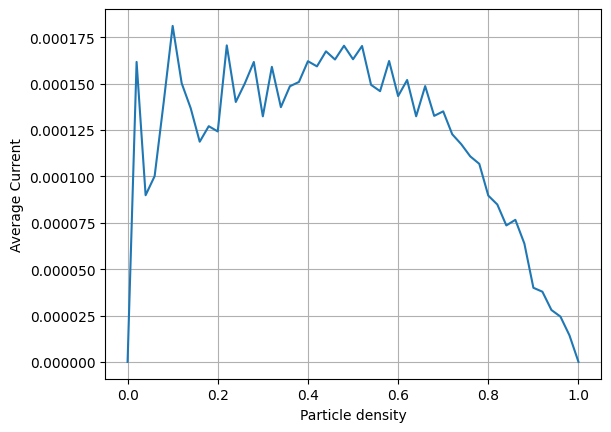

In [58]:
Oppgave4b(params4b)

I grafen over har vi plottet gjennomsnittsstrøm over alle sykler.

In [45]:
params4c = {
    "beta_k"  : 1000,
    "Nx"      : 100,
    "Tp"      : 300,  # Tid i et potensial
    "Ns"      : 10,
    "alfa"    : 0.2,  #Skaper positiv strøm.
    "b"       : 20,   # Størrelse på partiklene.
    "Nc"      : 100,  # Antallhalvperioder.
    "Np"      : 0 # Denne skal varieres for å danne forskjellige tetthet rho.
}
params4c["L"] = params4c["Ns"]*params4c["Nx"]
params4c["timeSteps"] = params4c["Tp"]*params4c["Nc"]

# params4c["initPositions"] = MakeParticles(params4c)  Denne må lages i funksjonen

params4c["tabell_V1_p_pos"], params4c["tabell_V1_p_neg"] = lookUpTabell_V1(params4c)
params4c["tabell_V2_p_pos"], params4c["tabell_V2_p_neg"] = lookUpTabell_V2(params4c)

In [46]:
def Oppgave4c(params):
    # KJører 4b) flere ganger. Endrer på Tp og Nc.
    # Nc_array = np.linspace(1, 30000, 10)  # Bør ikke ha jevnt stiigende verider.
    Nc_array = np.array([1, 2, 10, 50, 100, 500, 1000, 5000, 10000, 30000])
    # Nc_array =np.array([100])
    Tp_array = (30000 / Nc_array)
    for i in range(len(Nc_array)):
        params["Tp"] = Tp_array[i]
        params["Nc"] = Nc_array[i]
        print(f'Tid på et potensial Tp = {Tp_array[i]}')
        print(f'Antall sykluser Nc = {Nc_array[i]}')
        Oppgave4b(params)

Tid på et potensial Tp = 30000.0
Antall sykluser Nc = 1


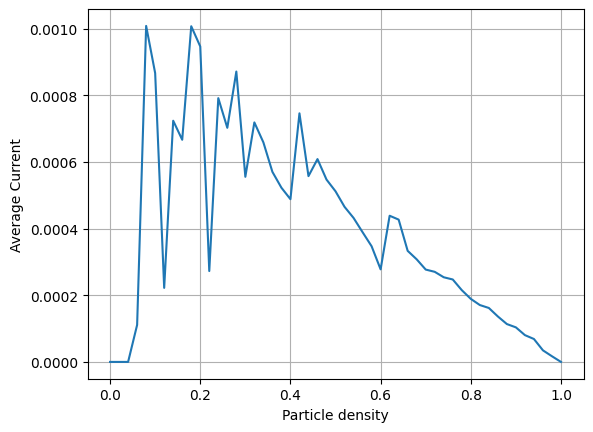

Tid på et potensial Tp = 15000.0
Antall sykluser Nc = 2


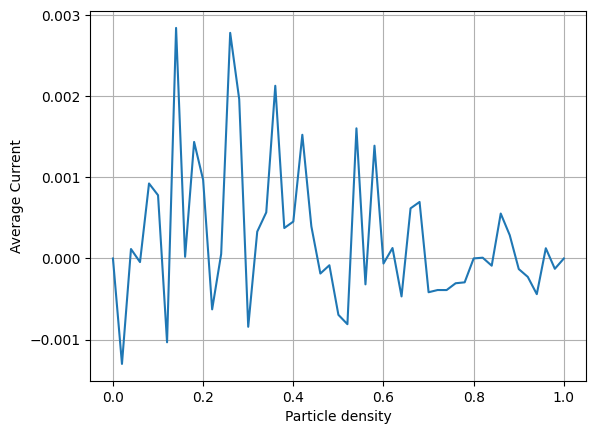

Tid på et potensial Tp = 3000.0
Antall sykluser Nc = 10


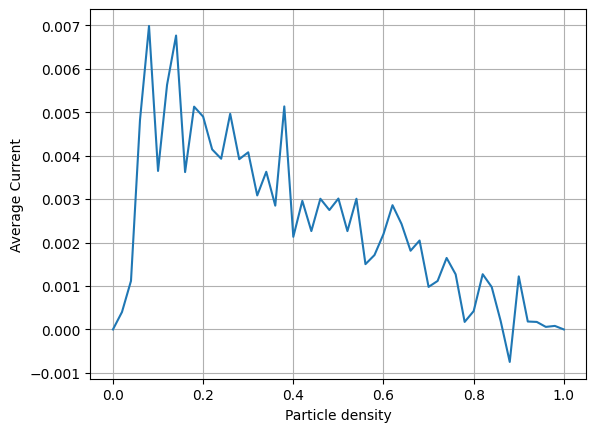

Tid på et potensial Tp = 600.0
Antall sykluser Nc = 50


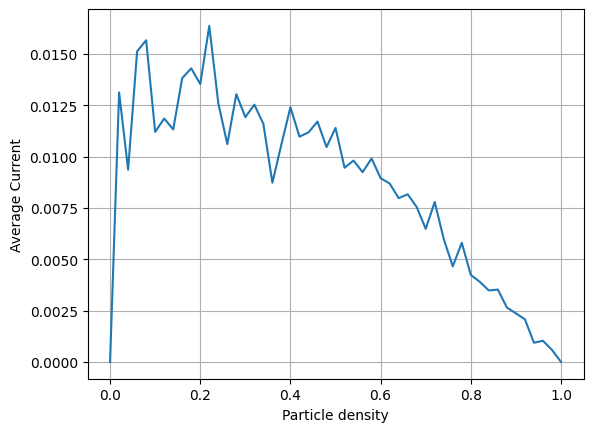

Tid på et potensial Tp = 300.0
Antall sykluser Nc = 100


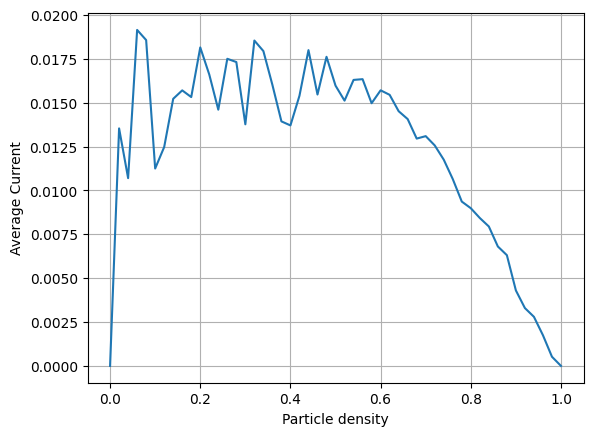

Tid på et potensial Tp = 60.0
Antall sykluser Nc = 500


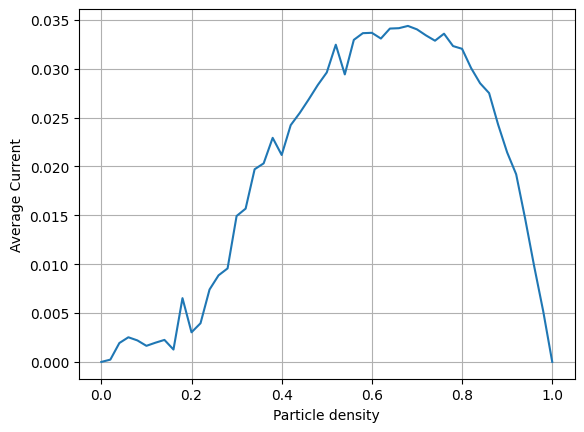

Tid på et potensial Tp = 30.0
Antall sykluser Nc = 1000


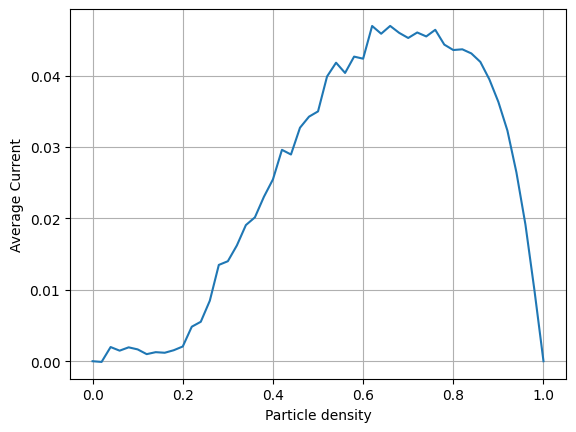

Tid på et potensial Tp = 6.0
Antall sykluser Nc = 5000


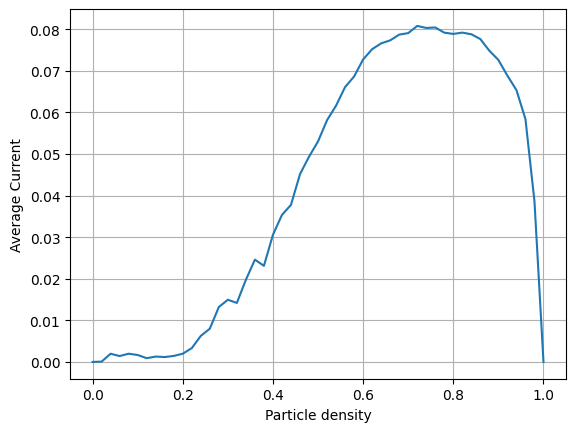

Tid på et potensial Tp = 3.0
Antall sykluser Nc = 10000


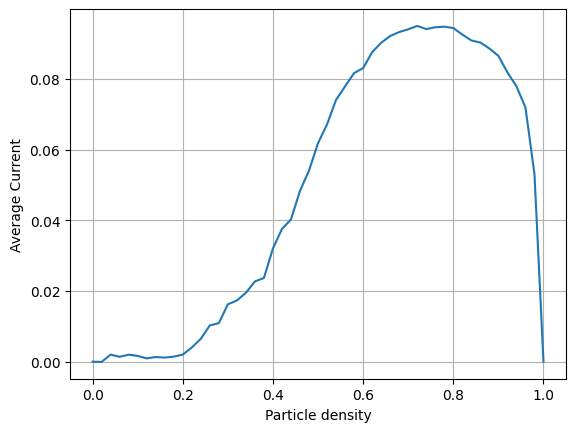

Tid på et potensial Tp = 1.0
Antall sykluser Nc = 30000


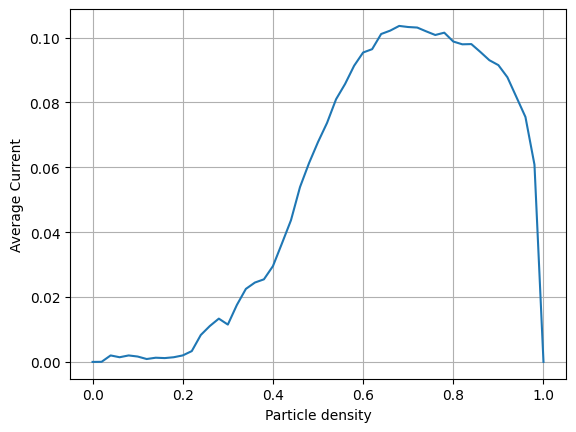

In [47]:
plt.close('all')
Oppgave4c(params4c)

## Oppgave 4d)

Vi skal nå finne en graf fra en naturvitenskapelig artikkel som handler om browninan motiton i en hard core repulsion flashing ratchet system, slik at vi kan sammenligne hard core repulsion med ikke-agerende

Her er linken til artikkelen Johannes.
Vi har hentet grafen fra denne artikkelen:
Memory-Induced Transport and Arrest in Flashing Ratchets: From Superdiffusion to Clustering
Karina I. Mazzitello, Daniel G. Zarlenga, Constancio M. Arizmendi
https://arxiv.org/html/2512.14891v1



Disse grafene beskriver partikler som beveger seg i et flashing ratchet potential, drevet av 

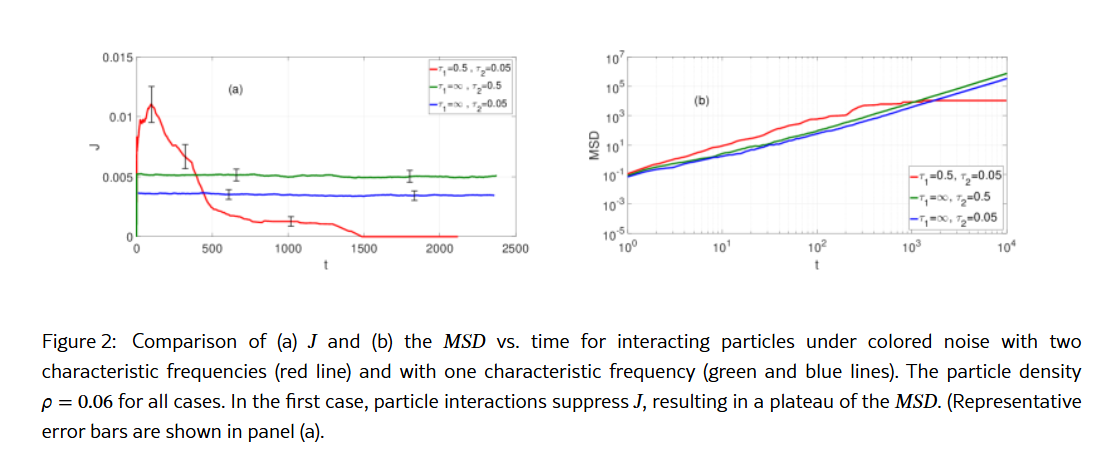